실습 6. 시계열 분해 시연·관찰
- 원본·추세·주기·나머지 네 부분으로 분해해 관찰

목표
- 시계열을 원본·추세·주기·나머지 네 부분으로 분해해 관찰(강사 시연)

단계
- 분해 도구로 시각 데이터를 더하기 모형으로 분해
- 원본·추세·계절·잔차 네 칸을 함께 보기
- 추세 칸이 이동평균 추세와 비슷한지 비교

예상 결과
- 네 칸으로 나뉜 분해 결과 — 추세는 상승, 주기는 반복 무늬

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/21_engine1_timestamp_sample.csv")

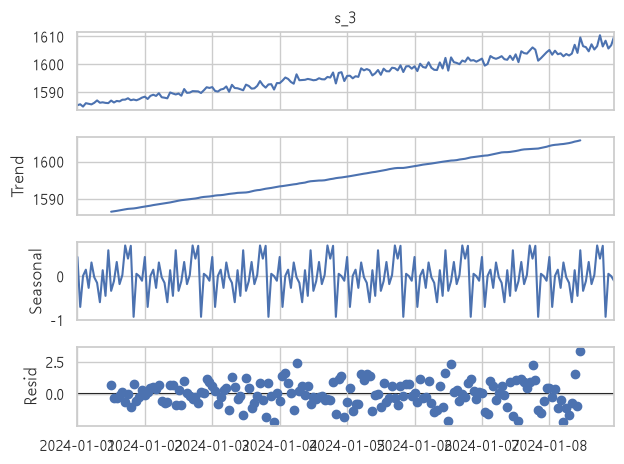

In [10]:
# [시계열 분해(Seasonal Decomposition)를 통한 시계열 구성 성분 추출]
# 1. seasonal_decompose: 신호를 장기 추세(Trend), 반복 주기(Seasonal), 그리고 무작위 잡음(Residual)의 합(additive)으로 분해합니다.
# 2. period=24: 매시 수집된 데이터에서 하루 주기(24시간)의 계절성이 반복된다고 명시적으로 정의합니다.
# * 센서 데이터에 복합적으로 꼬여있는 노이즈(Residual)와 근무 교대 주기(Seasonal)를 각각 분리하고,
#   오로지 기계의 노화 속도를 대변하는 순수 장기 신호(Trend)만 필터링하여 남기기 위한 통계적 전처리 기술입니다.
# * statsmodels의 seasonal_decompose는 데이터 내에 NaN(결측치)이 포함되어 있으면 실행 도중 에러를 유발하므로,
#   반드시 `interpolate()` 등으로 결측치를 완전 보정한 정제 상태에서 호출해야 합니다.
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')

from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['s_3'], model='additive', period=24)
result.plot()
plt.tight_layout()
plt.show()